In [1]:
import json

path = "/content/Dataset/"
files = [
    "Sports_and_Outdoors_5.json",
    "Home_and_Kitchen_5.json",
    "Electronics_5.json",
    "Cell_Phones_and_Accessories_5.json",
    "Beauty_5.json"
]

for f in files:
    with open(path + f, 'r') as file:
        line = file.readline()
        data = json.loads(line)
        print(f"--- {f} ---")
        print(list(data.keys()))
        print()

FileNotFoundError: [Errno 2] No such file or directory: '/content/Dataset/Sports_and_Outdoors_5.json'

In [12]:
import json,numpy as np,torch,torch.nn as nn,torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
from collections import Counter
import random,math,matplotlib.pyplot as plt,pickle,os
from sklearn.metrics import classification_report

In [13]:
path="/content/Dataset/"
fs=["Electronics_5.json","Beauty_5.json","Home_and_Kitchen_5.json"]
N=12000
data=[]
for f in fs:
    s=[]
    with open(path+f,'r') as file:
        for line in file:
            try:
                d=json.loads(line)
                if d.get('reviewText') and d.get('overall') and d.get('summary'):
                    s.append({'text':d['reviewText'],'rating':int(d['overall']),'summary':d['summary']})
            except:
                continue
            if len(s)==N:
                break
    data+=s
    print(f,len(s))
random.seed(42)
random.shuffle(data)
print("Total:",len(data))

Electronics_5.json 12000
Beauty_5.json 12000
Home_and_Kitchen_5.json 12000
Total: 36000


#Label+Preprocessing

In [14]:
def get_sent(r):
    if r<=2:return 0
    elif r==3:return 1
    else:return 2
def get_ll(t):
    l=len(t.split())
    if l<20:return 0
    elif l<60:return 1
    else:return 2
def clean(t):
    t=t.lower()
    t=''.join(c if c.isalnum() or c==' ' else ' ' for c in t)
    return ' '.join(t.split())
for d in data:
    d['sentiment']=get_sent(d['rating'])
    d['len_label']=get_ll(d['text'])
    d['text']=clean(d['text'])
    d['summary']=clean(d['summary'])
n=len(data)
ntr=int(0.7*n);nval=int(0.15*n)
tr=data[:ntr];val=data[ntr:ntr+nval];te=data[ntr+nval:]
print(len(tr),len(val),len(te))

25200 5400 5400


#Vocabulary

In [15]:
ML=128
PAD,UNK,BOS,EOS=0,1,2,3
def tok(t):return t.split()
cnt=Counter()
for d in tr:
    cnt.update(tok(d['text']))
    cnt.update(tok(d['summary']))
vocab={w:i+4 for i,(w,_) in enumerate(cnt.most_common(20000))}
vocab['<pad>']=PAD;vocab['<unk>']=UNK;vocab['<bos>']=BOS;vocab['<eos>']=EOS
iv={v:k for k,v in vocab.items()}
VS=len(vocab)
print("Vocab:",VS)
def enc_txt(t,ml=ML):
    ids=[vocab.get(w,UNK) for w in tok(t)[:ml]]
    ids+=[PAD]*(ml-len(ids))
    return ids

Vocab: 20004


#Dataset Class

In [16]:
class EncDS(Dataset):
    def __init__(self,d):
        self.d=d
    def __len__(self):return len(self.d)
    def __getitem__(self,i):
        d=self.d[i]
        x=torch.tensor(enc_txt(d['text']),dtype=torch.long)
        s=torch.tensor(d['sentiment'],dtype=torch.long)
        l=torch.tensor(d['len_label'],dtype=torch.long)
        return x,s,l
tds=EncDS(tr);vds=EncDS(val);eds=EncDS(te)
tdl=DataLoader(tds,batch_size=64,shuffle=True)
vdl=DataLoader(vds,batch_size=64)
edl=DataLoader(eds,batch_size=64)

#Encoder Model

In [17]:
dev=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class MHA(nn.Module):
    def __init__(self,d,h):
        super().__init__()
        self.h=h;self.dk=d//h
        self.wq=nn.Linear(d,d);self.wk=nn.Linear(d,d)
        self.wv=nn.Linear(d,d);self.wo=nn.Linear(d,d)
    def forward(self,x,mask=None):
        B,T,D=x.shape
        q=self.wq(x).view(B,T,self.h,self.dk).transpose(1,2)
        k=self.wk(x).view(B,T,self.h,self.dk).transpose(1,2)
        v=self.wv(x).view(B,T,self.h,self.dk).transpose(1,2)
        sc=(q@k.transpose(-2,-1))/math.sqrt(self.dk)
        if mask is not None:sc=sc.masked_fill(mask==0,-1e9)
        at=F.softmax(sc,dim=-1)
        out=(at@v).transpose(1,2).contiguous().view(B,T,D)
        return self.wo(out)
class EB(nn.Module):
    def __init__(self,d,h,ff):
        super().__init__()
        self.attn=MHA(d,h)
        self.ff=nn.Sequential(nn.Linear(d,ff),nn.ReLU(),nn.Linear(ff,d))
        self.n1=nn.LayerNorm(d);self.n2=nn.LayerNorm(d)
        self.drop=nn.Dropout(0.1)
    def forward(self,x,mask=None):
        x=self.n1(x+self.drop(self.attn(x,mask)))
        x=self.n2(x+self.drop(self.ff(x)))
        return x
class Enc(nn.Module):
    def __init__(self,vs,d=128,h=4,ff=256,nl=3):
        super().__init__()
        self.emb=nn.Embedding(vs,d,padding_idx=PAD)
        self.pe=nn.Embedding(ML,d)
        self.blocks=nn.ModuleList([EB(d,h,ff) for _ in range(nl)])
        self.fcs=nn.Linear(d,3);self.fcl=nn.Linear(d,3)
        self.drop=nn.Dropout(0.1)
    def forward(self,x):
        B,T=x.shape
        pos=torch.arange(T,device=x.device).unsqueeze(0)
        mask=(x!=PAD).unsqueeze(1).unsqueeze(2)
        out=self.drop(self.emb(x)+self.pe(pos))
        for b in self.blocks:out=b(out,mask)
        cls=out[:,0,:]
        return self.fcs(cls),self.fcl(cls),cls

#Train Model

Ep1 tr:0.6690 val:0.5739
Ep2 tr:0.5376 val:0.5185
Ep3 tr:0.4735 val:0.5319
Ep4 tr:0.4189 val:0.5013
Ep5 tr:0.3789 val:0.5210
Ep6 tr:0.3382 val:0.5107
Ep7 tr:0.3062 val:0.5985
Ep8 tr:0.2829 val:0.5809
Ep9 tr:0.2561 val:0.5994
Ep10 tr:0.2288 val:0.6623


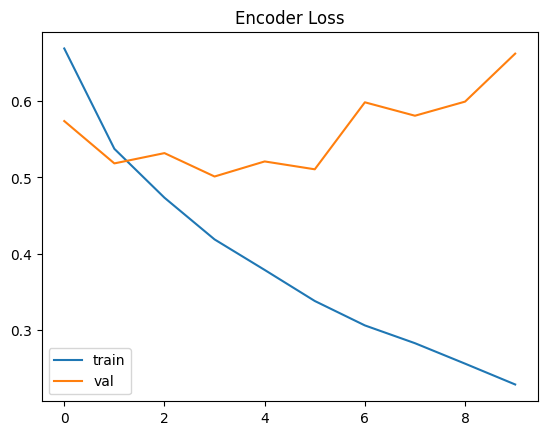

In [18]:
os.makedirs("results",exist_ok=True)
os.makedirs("models",exist_ok=True)
enc=Enc(VS).to(dev)
opt=torch.optim.Adam(enc.parameters(),lr=1e-3)
crit=nn.CrossEntropyLoss()
trl,vll=[],[]
for ep in range(10):
    enc.train();tl=0
    for x,s,l in tdl:
        x,s,l=x.to(dev),s.to(dev),l.to(dev)
        ps,pl,_=enc(x)
        loss=crit(ps,s)+crit(pl,l)
        opt.zero_grad();loss.backward();opt.step()
        tl+=loss.item()
    enc.eval();vl=0
    with torch.no_grad():
        for x,s,l in vdl:
            x,s,l=x.to(dev),s.to(dev),l.to(dev)
            ps,pl,_=enc(x)
            vl+=(crit(ps,s)+crit(pl,l)).item()
    trl.append(tl/len(tdl));vll.append(vl/len(vdl))
    print(f"Ep{ep+1} tr:{trl[-1]:.4f} val:{vll[-1]:.4f}")
plt.plot(trl,label='train');plt.plot(vll,label='val')
plt.legend();plt.title("Encoder Loss")
plt.savefig("results/enc_loss.png");plt.show()
torch.save(enc.state_dict(),"models/encoder.pt")

#Evalauate Encoder

In [20]:
# Cell 8 — Evaluate Encoder
enc.eval()
as_, ps_, al_, pl_ = [], [], [], []   # actuals / preds for sentiment & length

with torch.no_grad():
    for x, s, l in edl:
        x = x.to(dev)
        ps, pl, _ = enc(x)
        # FIX: was ps_.+= (syntax error) — corrected to ps_ +=
        ps_ += ps.argmax(1).cpu().tolist()
        pl_ += pl.argmax(1).cpu().tolist()
        as_ += s.tolist()
        al_ += l.tolist()

print("=== Sentiment Classification (Test Set) ===")
print(classification_report(as_, ps_, target_names=['Negative', 'Neutral', 'Positive']))

print("=== Length Label Classification (Test Set) ===")
print(classification_report(al_, pl_, target_names=['Short', 'Medium', 'Long']))

=== Sentiment Classification (Test Set) ===
              precision    recall  f1-score   support

    Negative       0.58      0.42      0.49       536
     Neutral       0.28      0.12      0.17       473
    Positive       0.88      0.96      0.92      4391

    accuracy                           0.83      5400
   macro avg       0.58      0.50      0.53      5400
weighted avg       0.80      0.83      0.81      5400

=== Length Label Classification (Test Set) ===
              precision    recall  f1-score   support

       Short       0.93      0.89      0.91       113
      Medium       0.99      0.98      0.99      2525
        Long       0.99      0.99      0.99      2762

    accuracy                           0.99      5400
   macro avg       0.97      0.96      0.96      5400
weighted avg       0.99      0.99      0.99      5400



In [ ]:
enc.eval()
all_embs,all_sents,all_texts=[],[],[]
dl_full=DataLoader(EncDS(tr),batch_size=128)
idx=0
with torch.no_grad():
    for x,s,l in dl_full:
        x=x.to(dev)
        _,_,cls=enc(x)
        all_embs.append(cls.cpu().numpy())
        all_sents+=s.tolist()
        batch_texts=[tr[idx+i]['text'] for i in range(len(s))]
        all_texts+=batch_texts
        idx+=len(s)
all_embs=np.concatenate(all_embs,axis=0)
with open("results/embeddings.pkl","wb") as f:
    pickle.dump({'embs':all_embs,'sents':all_sents,'texts':all_texts},f)
print("Saved embeddings:",all_embs.shape)